In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/dataset.csv")
df.columns = df.columns.str.strip()
df["Target_bin"] = (df["Target"] == "Dropout").astype(int)

In [4]:
drop_cols = [
    "Target",
    "Target_bin",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

X = df.drop(columns=drop_cols)
y = df["Target_bin"]

In [5]:
categorical_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

numeric_features = [col for col in X.columns if col not in categorical_features]

print("Numéricas:", len(numeric_features))
print("Categóricas:", len(categorical_features))

Numéricas: 10
Categóricas: 18


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(3539, 28) (885, 28)


In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

In [23]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [24]:
from sklearn.model_selection import GridSearchCV

svm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=42))
])

svm_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["rbf", "linear"],
    "model__gamma": ["scale", "auto"]
}

svm_search = GridSearchCV(
    svm_pipe,
    svm_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_search.fit(X_train, y_train)
print(svm_search.best_params_)
print(svm_search.best_score_)

{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
0.7539586321241113


In [25]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_search = GridSearchCV(
    rf_pipe,
    rf_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print(rf_search.best_params_)
print(rf_search.best_score_)

{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
0.73687538455078


In [26]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

gb_search = GridSearchCV(
    gb_pipe,
    gb_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gb_search.fit(X_train, y_train)
print(gb_search.best_params_)
print(gb_search.best_score_)

{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
0.76132967670078


In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": rf_search.best_estimator_.named_steps["model"],
    "Gradient Boosting": gb_search.best_estimator_.named_steps["model"],
    "SVM": svm_search.best_estimator_.named_steps["model"]
}

In [28]:
def evaluate_model(name, model, preprocessor, X_train, X_test, y_train, y_test):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    return pipe, results

In [29]:
trained_models = {}
results = []

for name, model in models.items():
    pipe, metrics = evaluate_model(name, model, preprocessor, X_train, X_test, y_train, y_test)
    trained_models[name] = pipe
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.871186,0.863248,0.711268,0.779923,0.912400
3,Gradient Boosting,0.859887,0.830579,0.707746,0.764259,0.907701
4,SVM,0.862147,0.864865,0.676056,0.758893,0.903790
2,Random Forest,0.858757,0.853333,0.676056,0.754420,0.901848
1,Decision Tree,0.783051,0.659722,0.669014,0.664336,0.752976


In [30]:
cv_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV F1", ascending=False)
cv_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
3,Gradient Boosting,0.858437,0.830573,0.703578,0.761330,0.899054
0,Logistic Regression,0.858434,0.831555,0.701812,0.760885,0.902291
4,SVM,0.856171,0.836531,0.686865,0.753959,0.897457
2,Random Forest,0.849393,0.840248,0.656983,0.736875,0.891299
1,Decision Tree,0.777910,0.652146,0.664008,0.657823,0.747916


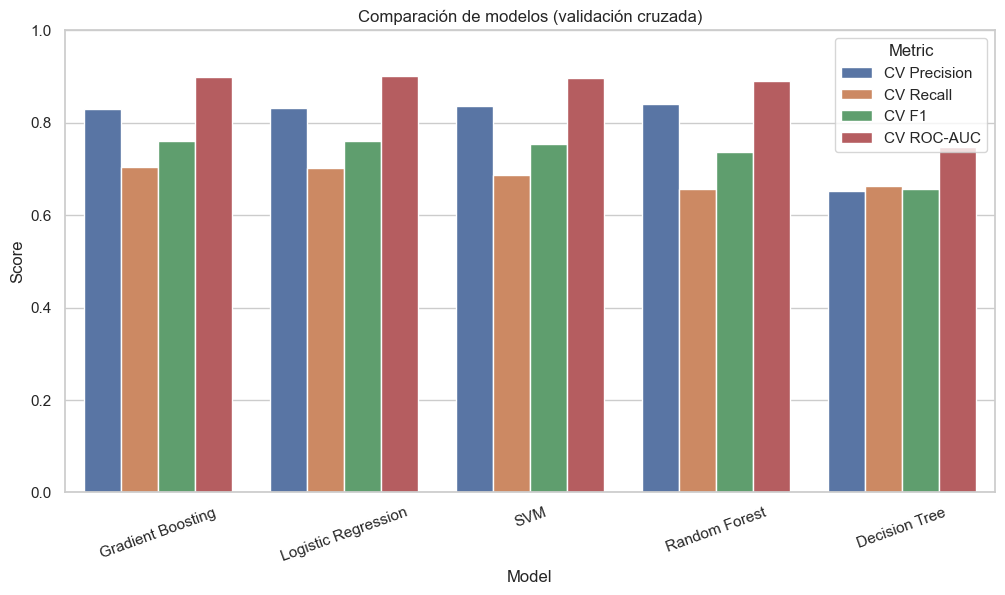

In [31]:
plot_df = cv_results_df.melt(
    id_vars="Model",
    value_vars=["CV Precision", "CV Recall", "CV F1", "CV ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.xticks(rotation=20)
plt.title("Comparación de modelos (validación cruzada)")
plt.ylim(0, 1)
plt.show()

In [32]:
best_model_name = cv_results_df.iloc[0]["Model"]
best_model_name

'Gradient Boosting'

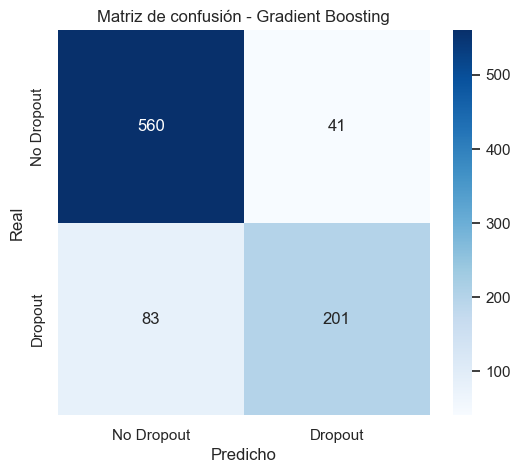

In [33]:
best_pipe = trained_models[best_model_name]
y_pred_best = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Dropout", "Dropout"],
    yticklabels=["No Dropout", "Dropout"]
)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.show()

In [34]:
final_comparison = results_df.merge(cv_results_df, on="Model")
final_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.871186,0.863248,0.711268,0.779923,0.912400,0.858434,0.831555,0.701812,0.760885,0.902291
1,Gradient Boosting,0.859887,0.830579,0.707746,0.764259,0.907701,0.858437,0.830573,0.703578,0.761330,0.899054
2,SVM,0.862147,0.864865,0.676056,0.758893,0.903790,0.856171,0.836531,0.686865,0.753959,0.897457
3,Random Forest,0.858757,0.853333,0.676056,0.754420,0.901848,0.849393,0.840248,0.656983,0.736875,0.891299
4,Decision Tree,0.783051,0.659722,0.669014,0.664336,0.752976,0.777910,0.652146,0.664008,0.657823,0.747916


In [35]:
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())
print(results_df)
print(cv_results_df.sort_values("CV F1", ascending=False))

(3539, 28) (885, 28)
0.3212771969482905 0.32090395480225986
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.871186   0.863248  0.711268  0.779923  0.912400
3    Gradient Boosting  0.859887   0.830579  0.707746  0.764259  0.907701
4                  SVM  0.862147   0.864865  0.676056  0.758893  0.903790
2        Random Forest  0.858757   0.853333  0.676056  0.754420  0.901848
1        Decision Tree  0.783051   0.659722  0.669014  0.664336  0.752976
                 Model  CV Accuracy  CV Precision  CV Recall     CV F1  \
3    Gradient Boosting     0.858437      0.830573   0.703578  0.761330   
0  Logistic Regression     0.858434      0.831555   0.701812  0.760885   
4                  SVM     0.856171      0.836531   0.686865  0.753959   
2        Random Forest     0.849393      0.840248   0.656983  0.736875   
1        Decision Tree     0.777910      0.652146   0.664008  0.657823   

   CV ROC-AUC  
3    0.899054  
0    0.902291  
4  